In [10]:
import pandas as pd
import numpy as np
from sklearn import tree

input_file = "../../data/PastHires.csv"
df = pd.read_csv(input_file, header=0)
# le os dados que estao em csv

In [11]:
df.head()
# mostra as 5 primeiras linhas

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


In [12]:
d = {'Y': 1, 'N':0}
df['Hired'] = df['Hired'].map(d)
# essas duas linhas fazem com que para cada dado de 'Hired' seja aplicado o dicionario em que S troca por 1 e N por 0
# isso 'traduz' para o modelo entender e diferenciar as duas respostas
df['Employed?'] = df['Employed?'].map(d)
df['Top-tier school'] = df['Top-tier school'].map(d)
df['Interned'] = df['Interned'].map(d)
# mesma coisa que anteriormente

d = {'BS': 0, 'MS': 1, 'PhD': 2}
df['Level of Education'] = df['Level of Education'].map(d)
df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0


In [13]:
features = list(df.columns[:6])
# separa as features que sao atributos da variavel alvo 'Hired'
features

['Years Experience',
 'Employed?',
 'Previous employers',
 'Level of Education',
 'Top-tier school',
 'Interned']

In [14]:
y = df["Hired"]
x = df[features]
clf = tree.DecisionTreeClassifier()
# pega o objeto tree classifier
clf = clf.fit(x, y)
# treina o modelo com as features e a variavel alvo

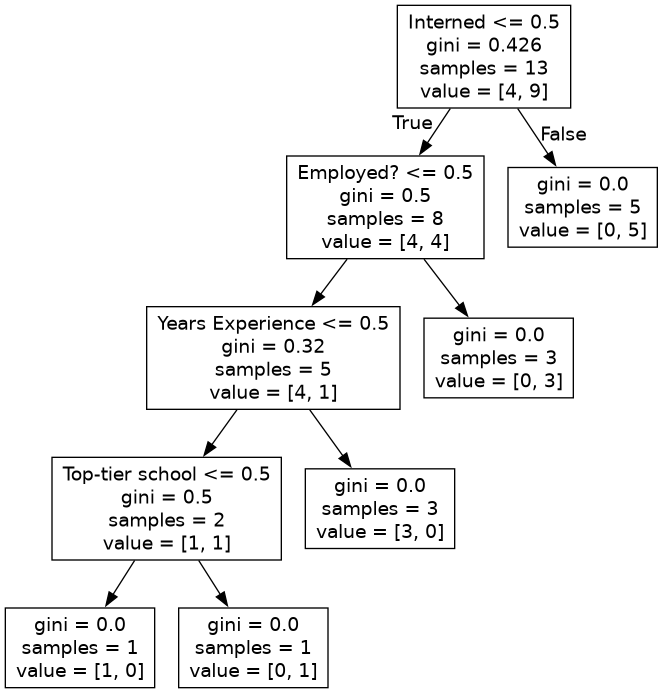

In [19]:
from IPython.display import Image
from io import StringIO
import pydot

dot_data = StringIO()
tree.export_graphviz(clf, out_file=dot_data,feature_names=features)

graph = pydot.graph_from_dot_data(dot_data.getvalue())
Image(graph[0].create_png())

### A imagem acima é um fluxo grama do modelo em suas dcisões perante os dados de treino. As perguntas de sim e nao, foram separadas em 0 e 1, entao o modelo corta com 0.5. Gini significa a entropia, samples, e quantos dados chegaram a esta decisão. Value significa o output de Hired, [SIM, Não]

In [23]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=10)
clf = clf.fit(x,y)

print(clf.predict([[10,1,4,0,0,0]]))
print(clf.predict([[10,0,4,0,0,0]]))

[1]
[0]


/home/beuren/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/beuren/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
